## Run PFM in fsLR space and generate dorsal parietal DAN patch size...

- chaining here?

https://github.com/MidnightScanClub/MSCcodebase/tree/master/Utilities/Infomap_wrapper

Gordon 2017 & salienceNetwork-Depression methods

In [1]:
from pathlib import Path
from config import OUTPUT_ROOT
import numpy as np
import nibabel as nib
import os.path as op

from neuromaps.datasets import fetch_atlas
fslr = fetch_atlas('fsLR', '32k')

print(sorted(fslr)) #['inflated', 'medial', 'midthickness', 'sphere', 'sulc', 'vaavg', 'veryinflated']
print(fslr['sphere'])

['inflated', 'medial', 'midthickness', 'sphere', 'sulc', 'vaavg', 'veryinflated']
Surface(L=PosixPath('/home/ubuntu/neuromaps-data/atlases/fsLR/tpl-fsLR_den-32k_hemi-L_sphere.surf.gii'), R=PosixPath('/home/ubuntu/neuromaps-data/atlases/fsLR/tpl-fsLR_den-32k_hemi-R_sphere.surf.gii'))


In [2]:
import nibabel as nib

fslr_left_infl = nib.load(fslr['inflated'].L)
vertices = fslr_left_infl.agg_data('NIFTI_INTENT_POINTSET')
print(vertices.shape[0])


32492


## Reference network map to fsLR
Save previous average DD-numrisk magjudge task consensus mapping in fsLR format for reference

In [ ]:
# load in previous average DD-numrisk magjudge task consensus mapping (mapped to ColeAnticevic nets)
bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
source_folder = op.join(bids_folder,'derivatives','networks_infomap_full') # old 'networks_infomap'
confspec = '36Pscrub3BPfilter'    
fn_target_labels_caNets = op.join(source_folder, f'sub-average_consensusMapping_confspec-{confspec}.npy') # mapped to ColeAnticevic nets
target_labels_caNets = np.load(fn_target_labels_caNets)

import nibabel as nib
from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

full_array = np.zeros(20484, dtype=np.float32)
full_array[mask] = target_labels_caNets.astype(np.float32)



In [ ]:
# transform to fsLR space using neuromaps
n_per_hemi = 10242
def array_to_gifti(arr):
    darray = nib.gifti.GiftiDataArray(
        data=arr.astype(np.float32),
        intent=nib.nifti1.intent_codes['NIFTI_INTENT_NONE'],
        datatype='NIFTI_TYPE_FLOAT32'
    )
    return nib.gifti.GiftiImage(darrays=[darray])

lh_img = array_to_gifti(full_array[:n_per_hemi])
rh_img = array_to_gifti(full_array[n_per_hemi:])

from neuromaps import transforms
lh_fslr, rh_fslr = transforms.fsaverage_to_fslr((lh_img, rh_img), 
                                                target_density='32k',
                                                method='nearest' # for discrete labels
                                                )


In [ ]:
# save transformed atlas in fsLR space as .label.gii (for visualization in wb_view) and .npz (for overlap computation in labeling step)
atlas_dir = OUTPUT_ROOT / 'atlases'
atlas_dir.mkdir(parents=True, exist_ok=True)

def array_to_label_gifti(arr):
    """Save integer label array as GiftiImage (NIFTI_INTENT_LABEL, INT32)."""
    darray = nib.gifti.GiftiDataArray(
        data=arr.astype(np.int32),
        intent=nib.nifti1.intent_codes['NIFTI_INTENT_LABEL'],
        datatype='NIFTI_TYPE_INT32'
    )
    return nib.gifti.GiftiImage(darrays=[darray])

# Extract arrays from the transformed GiftiImages
lh_labels = lh_fslr.darrays[0].data.astype(np.int32)  # (32492,)
rh_labels = rh_fslr.darrays[0].data.astype(np.int32)  # (32492,)

# Save as .label.gii (viewable in wb_view)
nib.save(array_to_label_gifti(lh_labels),
         str(atlas_dir / 'caNets_DDnr-magjudge-task-average-from-fsav5_space-fsLR_den-32k_hemi-L.label.gii'))
nib.save(array_to_label_gifti(rh_labels),
         str(atlas_dir / 'caNets_DDnr-magjudge-task-average-from-fsav5_space-fsLR_den-32k_hemi-R.label.gii'))

# Save concatenated cortical array as .npz (for overlap computation in labeling step)
np.savez(atlas_dir / 'caNets_DDnr-magjudge-task-average-from-fsav5_space-fsLR_den-32k_cortex.npz',
         labels=np.concatenate([lh_labels, rh_labels]),  # (64984,)
         hemi=np.array(['L'] * len(lh_labels) + ['R'] * len(rh_labels)))

print(f'Saved to {atlas_dir}')


Saved to /mnt_03/ds-dnumrisk/derivatives/pfm_fslr/atlases


## Gordon 17 - 17nets atlas

In [9]:
from scipy.io import loadmat

source_atlas_dir = '/mnt_04/cbig_network_correspondence_data/atlases'
atlas_name = 'Gordon_17'
space = 'fs_LR_32k'
team = 'WashU' # os.listdir(op.join(atlas_dir, space, 'WashU'))
atlas= loadmat(op.join(source_atlas_dir, space, team, 'EG17.mat')) # Evan Gordon 17-network atlas

# Extract arrays from the transformed GiftiImages
lh_labels = atlas["lh_labels"].flatten().astype(np.int32)  # (32492,)
rh_labels = atlas["rh_labels"].flatten().astype(np.int32)  # (32492,)

subject = atlas_name # for plotting purposes

In [10]:
# Save concatenated cortical array as .npz (for overlap computation in labeling step)
np.savez(atlas_dir / 'gordon17_space-fsLR_den-32k_cortex.npz',
         labels=np.concatenate([lh_labels, rh_labels]),  # (64984,)
         hemi=np.array(['L'] * len(lh_labels) + ['R'] * len(rh_labels)))
print(f'Saved Gordon 17 atlas to {atlas_dir}/gordon17_space-fsLR_den-32k_cortex.npz')

Saved Gordon 17 atlas to /mnt_03/ds-dnumrisk/derivatives/pfm_fslr/atlases/gordon17_space-fsLR_den-32k_cortex.npz


## Visualize

In [3]:
from utils_01 import get_gordon17_cmap, get_CANets_cmap

cmap_gordon, gordon17_network_names = get_gordon17_cmap()
cmap_ca = get_CANets_cmap()


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [4]:
# visualize the transformed atlas in fsLR space
atlas_dir = OUTPUT_ROOT / 'atlases'
data = np.load(atlas_dir / 'caNets_DDnr-magjudge-task-average-from-fsav5_space-fsLR_den-32k_cortex.npz')
labels = data['labels']  # (64984,)
hemi = data['hemi']      # (64984,)

lh_labels = labels[hemi == 'L']  # (32492,)
rh_labels = labels[hemi == 'R']  # (32492,)


In [5]:
def prep_labels_for_visualization(labels, valid_mask):
    # --- load ROI masks (True = non-medial-wall)
    from config import HCP_ATLASES

    roi_L = nib.load(HCP_ATLASES / 'L.atlasroi.32k_fs_LR.shape.gii').darrays[0].data.astype(bool)
    roi_R = nib.load(HCP_ATLASES / 'R.atlasroi.32k_fs_LR.shape.gii').darrays[0].data.astype(bool)
    n_L_cortex = roi_L.sum()   # 29696


    # --- step 1: n_valid_nodes → 59412
    cifti_labels = np.zeros(len(valid_mask), dtype=np.int32)
    cifti_labels[valid_mask] = labels

    # --- step 2: 59412 → 32492 per hemisphere (insert 0 at medial wall)
    lh_labels = np.zeros(len(roi_L), dtype=np.int32)
    rh_labels = np.zeros(len(roi_R), dtype=np.int32)
    lh_labels[roi_L] = cifti_labels[:n_L_cortex]
    rh_labels[roi_R] = cifti_labels[n_L_cortex:]

    return lh_labels, rh_labels

In [ ]:
subject = 'sub-01'
ref_name = 'caNets_DDnr'
cmap_atlas = cmap_ca
# --- load network labels (n_valid_nodes,)
net = np.load(OUTPUT_ROOT / subject / 'networks' /
              f'{subject}_ses-1_space-fsLR32k_consensus_ref-{ref_name}_communities.npz')
network_labels = net['network_labels']
meta = np.load(OUTPUT_ROOT / subject / 'cm' / f'{subject}_ses-1_space-fsLR32k_cm_meta.npz')
valid_mask = meta['valid_mask']   # (59412,) bool

lh_labels, rh_labels = prep_labels_for_visualization(network_labels, valid_mask)


In [6]:
subject = 'sub-01'
ref_name = 'gordon17'
cmap_atlas = cmap_gordon

# --- load network labels (n_valid_nodes,)
net = np.load(OUTPUT_ROOT / subject / 'networks' /
              f'{subject}_ses-1_space-fsLR32k_consensus_ref-{ref_name}_communities.npz')
network_labels = net['network_labels']
meta = np.load(OUTPUT_ROOT / subject / 'cm' / f'{subject}_ses-1_space-fsLR32k_cm_meta.npz')
valid_mask = meta['valid_mask']   # (59412,) bool

lh_labels, rh_labels = prep_labels_for_visualization(network_labels, valid_mask)


In [31]:
cmap, names = get_gordon17_cmap()

cmap_atlas = cmap


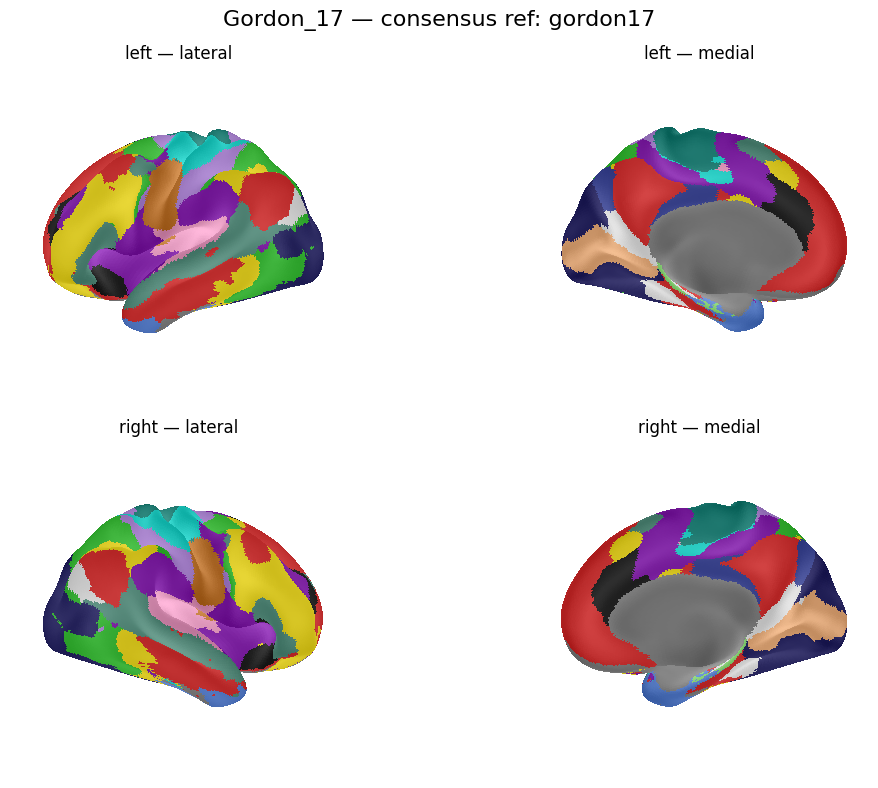

In [32]:
from nilearn import plotting
import matplotlib.pyplot as plt

# inflated surfaces for visualization (already fetched earlier)
lh_surf = str(fslr['inflated'].L)  # path to .surf.gii
rh_surf = str(fslr['inflated'].R)


fig, axes = plt.subplots(2, 2, subplot_kw={'projection': '3d'}, figsize=(12, 8))

for ax, surf, data, hemi, view in zip(
    axes.flat,
    [lh_surf, lh_surf, rh_surf, rh_surf],
    [lh_labels, lh_labels, rh_labels, rh_labels],
    ['left', 'left', 'right', 'right'],
    ['lateral', 'medial', 'lateral', 'medial']
):
    plotting.plot_surf(
        surf, data,
        hemi=hemi, view=view,
        cmap=cmap_atlas,         # discrete colormap, up to 20 networks
        vmin=0, 
        vmax=12 if ref_name == 'caNets_DDnr' else 17, # adjust vmax based on the number of networks in the atlas
        avg_method = 'median',
        darkness=1.0,
        colorbar=False,
        bg_map=str(fslr['sulc'].L if hemi == 'left' else fslr['sulc'].R),
        bg_on_data=True,
        axes=ax
    )
    ax.set_title(f'{hemi} — {view}')
fig.suptitle(f'{subject} — consensus ref: {ref_name}', fontsize=16)
plt.tight_layout()
plt.show()


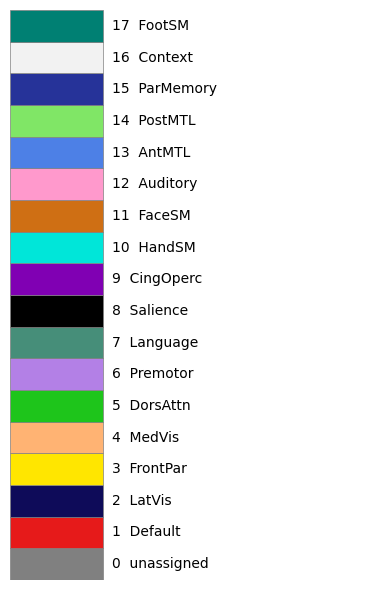

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.insert(0, '/home/ubuntu/git/parietal_patterns/nets_PFM')
from utils_01 import get_gordon17_cmap

cmap, names = get_gordon17_cmap()

fig, ax = plt.subplots(figsize=(4, 6))
for i, (name, color) in enumerate(zip(names, cmap.colors)):
    ax.add_patch(plt.Rectangle((0, i), 1, 1, color=color,
                                ec='grey', lw=0.5))
    ax.text(1.1, i + 0.5, f'{i}  {name}', va='center', fontsize=10)

ax.set_xlim(0, 4)
ax.set_ylim(0, len(names))
ax.axis('off')
plt.tight_layout()
plt.show()


## Debug

first subject map looks bad


In [51]:
density = '003'
net = np.load(OUTPUT_ROOT / subject / 'networks' /
              f'{subject}_ses-1_space-fsLR32k_density-003_ref-caNets_DDnr_communities.npz')
network_labels = net['network_labels']
lh_labels, rh_labels = prep_labels_for_visualization(network_labels, valid_mask)

In [57]:
for density in INFOMAP_DENSITIES:
    print (f'Density: {density}')

Density: 0.003
Density: 0.005
Density: 0.01
Density: 0.02
Density: 0.03
Density: 0.05


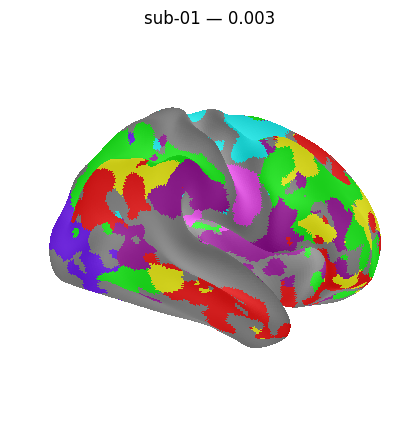

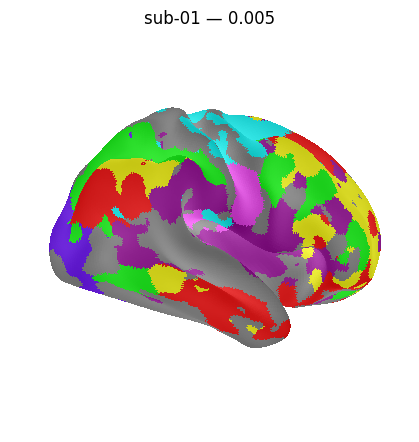

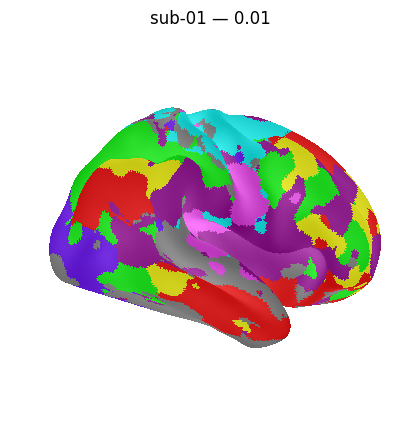

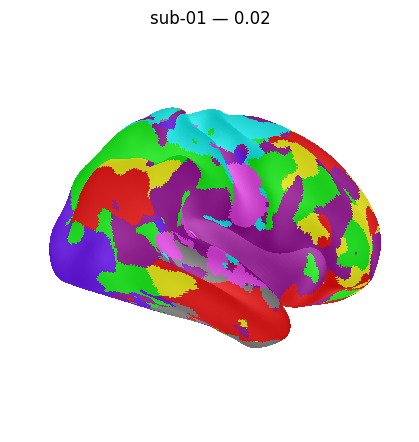

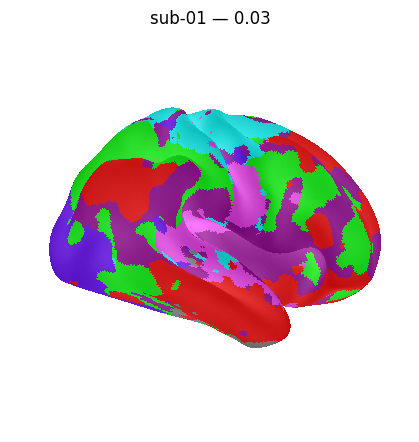

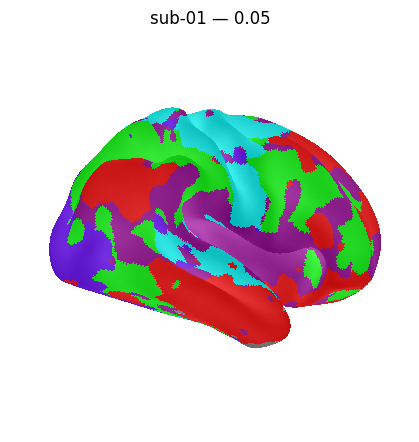

In [58]:
from config import INFOMAP_DENSITIES

for density in INFOMAP_DENSITIES:
    d_str   = f'{density:.3f}'.replace('0.', '')
    net = np.load(OUTPUT_ROOT / subject / 'networks' /
              f'{subject}_ses-1_space-fsLR32k_density-{d_str}_ref-caNets_DDnr_communities.npz')
    network_labels = net['network_labels']
    lh_labels, rh_labels = prep_labels_for_visualization(network_labels, valid_mask)
    
    data = rh_labels
    plotting.plot_surf(
        surf, data,
        hemi=hemi, view='lateral',
        cmap=cmap_ca,         # discrete colormap, up to 20 networks
        vmin=0, vmax=12,
        avg_method = 'median',
        darkness=1.0,
        colorbar=False,
        bg_map=str(fslr['sulc'].L if hemi == 'left' else fslr['sulc'].R),
        bg_on_data=True,
    )
    plt.title(f'{subject} — {density}')

In [59]:
def consensus_assignment(all_modules: list[np.ndarray]) -> np.ndarray:
    """
    Collapse assignments across thresholds (sparse → dense).
    Each node gets the label from the sparsest threshold where it is assigned.
    Nodes unassigned at all thresholds stay 0.
    all_modules must be ordered sparse → dense (matches INFOMAP_DENSITIES).
    """
    n_nodes = all_modules[0].shape[0]
    consensus = np.zeros(n_nodes, dtype=np.int32)

    for modules in all_modules:   # sparse → dense
        update = (consensus == 0) & (modules > 0)
        consensus[update] = modules[update]

    return consensus

In [60]:
all_modules = []
for density in INFOMAP_DENSITIES:
    d_str   = f'{density:.3f}'.replace('0.', '')
    net = np.load(OUTPUT_ROOT / subject / 'networks' /
              f'{subject}_ses-1_space-fsLR32k_density-{d_str}_ref-caNets_DDnr_communities.npz')
    network_labels = net['network_labels']
    all_modules.append(network_labels)

In [61]:
consensus = consensus_assignment(all_modules)

Text(0.5, 0.92, 'sub-01 — 0.05')

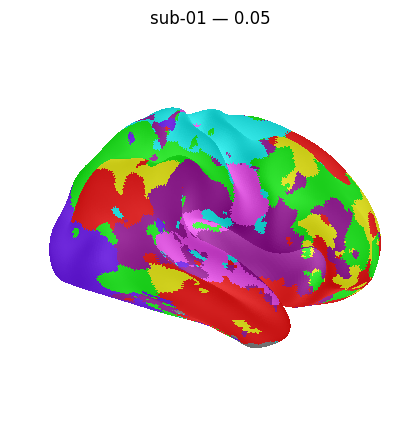

In [62]:
lh_labels, rh_labels = prep_labels_for_visualization(consensus, valid_mask)

data = rh_labels
plotting.plot_surf(
    surf, data,
    hemi=hemi, view='lateral',
    cmap=cmap_ca,         # discrete colormap, up to 20 networks
    vmin=0, vmax=12,
    avg_method = 'median',
    darkness=1.0,
    colorbar=False,
    bg_map=str(fslr['sulc'].L if hemi == 'left' else fslr['sulc'].R),
    bg_on_data=True,
)
plt.title(f'{subject} — {density}')